# Import Libraries

In [25]:
import sys
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import sys  # Used in process_single_run to suppress game-by-game output
from io import StringIO # Used in process_single_run to suppress game-by-game output
import warnings
from requests.exceptions import RequestsDependencyWarning
from typing import List, Optional

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Custom imports from the project
from common.utils import load_config, setup_environment_and_agent, generate_video
from evaluate import play_one_game, evaluate_agent, calculate_summary_stats, find_checkpoints

# Configure for high quality plots
%matplotlib inline
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

# Suppress specific warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*You are using `torch.load`.*")
warnings.filterwarnings("ignore", category=RequestsDependencyWarning)
print("warnings configured")

warnings configured


# Helper Functions

In [26]:
# Cell 3: Core Analysis Functions

def process_single_run(run_path: Path, num_eval_games: int, target_timesteps: Optional[List[int]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Processes a single experimental run folder, evaluates all its checkpoints,
    and returns the aggregated raw and summary data for that run.

    Parameters:
    - run_path (Path): Path to the run folder (e.g., models/dqn_run_01)
    - num_eval_games (int): Number of games to play per checkpoint for evaluation.
    - target_timesteps (Optional[List[int]]): If provided, only evaluate checkpoints at these timesteps.   

    Returns:
    - tuple: (raw_df, summary_df) DataFrames for this run.
        raw_df: Detailed game-by-game results for all checkpoints in this run.
        summary_df: Aggregated summary statistics per checkpoint in this run.
    """
    #print(f"\n{'='*25} Processing Run: {run_path.name} {'='*25}")
    
    # --- 1. Identify Agent and Load Config ---
    # Infer agent type and config path from the folder structure
    agent_type = run_path.parent.name.split('_')[0].lower()
    config_path = project_root / "configs" / f"{agent_type}_config.yaml"
    
    if not config_path.exists():
        print(f"  [!] Warning: Config file not found at {config_path}. Skipping run.")
        return pd.DataFrame(), pd.DataFrame()
        
    config = load_config(config_path)
    config['agent'] = agent_type
    
    # --- 2. Find Checkpoints ---
    # Use our robust function from evaluate.py
    checkpoint_paths = find_checkpoints(run_path)
    if not checkpoint_paths:
        print(f"  [!] Warning: No checkpoints found. Skipping run.")
        return pd.DataFrame(), pd.DataFrame()
    
    if target_timesteps:
        filtered_paths = []
        target_set = set(target_timesteps)
        for path in checkpoint_paths:
            match = re.search(r'step_(\d+)\.pth$', path.name)
            if match:
                timestep = int(match.group(1))
                if timestep in target_set:
                    filtered_paths.append(path)

        if not filtered_paths:
            print(f"  [!] Warning: No checkpoints matched target timesteps {target_timesteps}. Skipping run.")
            return pd.DataFrame(), pd.DataFrame()
        
        checkpoint_paths_to_process = filtered_paths

    else:
        checkpoint_paths_to_process = checkpoint_paths  # Use all found checkpoints
        
    # --- 3. Setup Environment and Agent (ONCE PER RUN for efficiency) ---
    #print(f"\nSetting up environment and agent for '{agent_type.upper()}'...")
    env, agent, device = setup_environment_and_agent(config)
    
    # --- 4. Loop Through Checkpoints and Evaluate ---
    all_checkpoints_summaries = []
    all_checkpoints_raw_data = []

    checkpoint_prog_bar = tqdm(checkpoint_paths_to_process, desc=f"Evaluating {run_path.name}", leave=False)
    for model_path in checkpoint_prog_bar:
        try:
            timestep = int(re.search(r'step_(\d+)\.pth$', model_path.name).group(1))
            checkpoint_prog_bar.set_postfix_str(f"t={timestep}")
            
            # Load model weights into the EXISTING agent
            agent.load(str(model_path))

            #original_stdout = sys.stdout  # Save a reference to the original standard output
            #sys.stdout = StringIO()       # Redirect standard output to suppress game-by-game output
            
            # --- THIS IS THE CRITICAL CHANGE ---
            # Call our new, clean evaluate_agent function
            raw_df_for_checkpoint = evaluate_agent(agent, env, num_games=num_eval_games, show_progress=False)

            #sys.stdout = original_stdout  # Reset standard output to original

            # Calculate summary stats for this checkpoint
            summary_df_for_checkpoint = calculate_summary_stats(raw_df_for_checkpoint)
            
            # Add metadata for aggregation and plotting
            raw_df_for_checkpoint['timestep'] = timestep
            summary_df_for_checkpoint['timestep'] = timestep
            
            all_checkpoints_raw_data.append(raw_df_for_checkpoint)
            all_checkpoints_summaries.append(summary_df_for_checkpoint)

        except Exception as e:
            #sys.stdout = original_stdout  # Ensure we reset stdout on error
            print(f"  [!] Failed to evaluate checkpoint {model_path.name}. Error: {e}")
            
    # --- 5. Aggregate Data and Clean Up ---
    env.close() # Close the env to free up resources

    if not all_checkpoints_summaries:
        print(f"  [!] No checkpoints were successfully evaluated for {run_path.name}.")
        return pd.DataFrame(), pd.DataFrame()
        
    # Combine all results for this single run
    run_raw_df = pd.concat(all_checkpoints_raw_data, ignore_index=True)
    run_summary_df = pd.concat(all_checkpoints_summaries, ignore_index=True)
    
    # Add run-level metadata
    run_raw_df['run_name'] = run_path.name
    run_summary_df['run_name'] = run_path.name
    run_raw_df['agent_type'] = agent_type
    run_summary_df['agent_type'] = agent_type
    
    #print(f"\n{'='*25} Finished Processing Run: {run_path.name} {'='*25}")
    return run_raw_df, run_summary_df

def run_full_analysis(base_models_dir: Path, num_eval_games: int, target_timesteps: Optional[List[int]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Orchestrates the entire analysis. Discovers all runs, processes them,
    and returns two master DataFrames with all results.

    Parameters:
    - base_models_dir (Path): Path to the base models directory (e.g., models
    - num_eval_games (int): Number of games to play per checkpoint for evaluation.
    - target_timesteps (Optional[List[int]]): If provided, only evaluate checkpoints at these timesteps.

    Returns:
    - tuple: (master_raw_df, master_summary_df)
        master_raw_df: Detailed game-by-game results for all runs and checkpoints.
        master_summary_df: Aggregated summary statistics per run and checkpoint.
    """

    # --- 1. Discover all run paths (using our revised discovery logic) ---
    run_paths = []
    agent_checkpoint_dirs = [p for p in base_models_dir.iterdir() if p.is_dir()]
    for agent_dir in agent_checkpoint_dirs:
        runs_in_dir = [p for p in agent_dir.iterdir() if p.is_dir() and not p.name.startswith('.')]
        run_paths.extend(runs_in_dir)
    run_paths.sort(key=lambda p: p.name)

    if not run_paths:
        print(f"No run folders found in {base_models_dir}. Analysis cannot proceed.")
        return pd.DataFrame(), pd.DataFrame()
    
    print(f"Found {len(run_paths)} total experiment runs to analyze.")
    
    # --- 2. Process each run and collect results ---
    all_runs_raw = []
    all_runs_summaries = []
    
    for path in tqdm(run_paths, desc="Processing Runs"):
        raw_df, summary_df = process_single_run(run_path=path, num_eval_games=num_eval_games, target_timesteps=target_timesteps)
        if not raw_df.empty:
            all_runs_raw.append(raw_df)
            all_runs_summaries.append(summary_df)
            
    # --- 3. Final Aggregation ---
    if not all_runs_raw:
        print("\n\nNo data was successfully processed. Master DataFrames will be empty.")
        return pd.DataFrame(), pd.DataFrame()
        
    master_raw_df = pd.concat(all_runs_raw, ignore_index=True)
    master_summary_df = pd.concat(all_runs_summaries, ignore_index=True)
    
    print("\n\nFull analysis complete. Master DataFrames are ready.")
    return master_raw_df, master_summary_df

In [27]:
def plot_comparative_learning_curves(master_summary_df: pd.DataFrame, num_eval_games: int) -> None:
    """
    Plots comparative learning curves for all runs in the master summary DataFrame.

    Parameters:
    - master_summary_df (DataFrame): Aggregated summary statistics for all runs.
    - num_eval_games (int): Number of evaluation games used to compute mean scores.

    Returns:
    - None (displays the plot)
    """
    if master_summary_df.empty:
        print("Master summary DataFrame is empty. Cannot plot learning curves.")
        return

    print("\nGenerating comparative learning curves...")
    g = sns.relplot(
        data=master_summary_df,
        x="timestep",
        y="mean_score",
        hue="run_name",
        col="agent_type",
        kind="line",
        marker="o",
        height=7,
        aspect=1.5,
        facet_kws={'sharey': False, 'sharex': True},
    )

    # Add error bands for standard deviation
    for agent_type, ax in g.axes_dict.items():
        agent_df = master_summary_df[master_summary_df['agent_type'] == agent_type]
        for run_name in agent_df['run_name'].unique():
            run_data = agent_df[agent_df['run_name'] == run_name]
            ax.fill_between(
                run_data['timestep'],
                run_data['mean_score'] - run_data['std_score'],
                run_data['mean_score'] + run_data['std_score'],
                alpha=0.2,
            )

    # Customize legend
    legend = g.legend
    if legend: # Check if a legend exists before trying to modify it
        legend.set(title="Experimental Runs", loc='upper left', bbox_to_anchor=(0.10, 0.95), frame_on=True)
        legend.get_frame().set_facecolor('white') # Set the background color
        legend.get_frame().set_edgecolor('black') # Set the border color


    # Add titles and labels
    g.figure.suptitle("Comparative Learning Curves: Mean Score vs. Training Steps", y=1.03, fontsize=16)
    g.set_axis_labels("Training Timesteps", f"Mean Score (over {num_eval_games} games)")
    g.set_titles("Agent: {col_name}")
    plt.tight_layout(pad=0.1)

    plt.show()

def plot_final_box_whisker(master_raw_df: pd.DataFrame, master_summary_df: pd.DataFrame, num_eval_games: int) -> None:
    """
    Plots box-and-whisker plots of final evaluation scores for each run.

    Parameters:
    - master_raw_df (DataFrame): Detailed game-by-game results for all runs.
    - master_summary_df (DataFrame): Aggregated summary statistics for all runs.
    - num_eval_games (int): Number of evaluation games used to compute mean scores.

    Returns:
    - None (displays the plot)
    """
    print("\nGenerating final box-and-whisker plots...")

    last_timestep_df = master_summary_df.loc[master_summary_df.groupby('run_name')['timestep'].idxmax()]
    final_raw_df = master_raw_df[master_raw_df['timestep'].isin(last_timestep_df['timestep'])]

    plt.figure(figsize=(12, 7))

    sns.boxplot(
        data=final_raw_df,
        x='run_name',
        y='score',
        hue='agent_type',
        palette='colorblind',
    )

    plt.title(f'Final Evaluation Score Distribution (over {num_eval_games} games)', fontsize=16)
    plt.xlabel('Experimental Runs', fontsize=12)
    plt.ylabel(f'Score (over {num_eval_games})', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Agent Type', loc='upper right')

    plt.tight_layout()

    plt.show()




#----------------------------------------------------------------------------- Old plotting functions (for single runs)

def plot_mean_score_vs_steps(summary_df: pd.DataFrame, run_name: str) -> None:
    """
    Plot mean score vs training steps with error bars.

    Parameters:
    - summary_df: DataFrame containing summary statistics indexed by timestep.
    - run_name: Name of the run for labeling the plot.

    Returns:
    - None (displays the plot)
    """
    run_number = summary_df['run_number'].iloc[0] 
    plot_label = f"Run {run_number}"

    plt.figure(figsize=(12, 7))

    plot_df = summary_df.reset_index()

    # Get the data for the plot
    timesteps = plot_df['timestep']
    mean_scores = plot_df['mean_score']
    std_scores = plot_df['std_score']

    plt.plot(timesteps, mean_scores, marker='o', linestyle='-', label=f'{plot_label} (Mean Score)')
    plt.fill_between(timesteps, mean_scores - std_scores, mean_scores + std_scores, alpha=0.2, label=f'{plot_label} (Std Dev)')

    plt.title(f'Agent Performance vs Training Steps ({run_name})', fontsize=16)
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Mean Score', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.legend()

    plt.show()

def plot_score_distribution_vs_steps(raw_df: pd.DataFrame, run_name: str) -> None:
    """ Creates a box plot of score distributions for each checkpoint.
     
    Parameters:
    - raw_df: DataFrame containing raw evaluation results with 'timestep' and 'score' columns.
    - run_name: Name of the run for labeling the plot.
      
    Returns:
    - None (displays the plot)
    """

    run_number = raw_df['run_number'].iloc[0]

    plt.figure(figsize=(12, 7))
    
    sns.boxplot(x='timestep', y='score', data=raw_df)
    
    plt.title(f'Score Distribution vs. Training Timesteps ({run_name})', fontsize=16)
    plt.xlabel('Training Timesteps', fontsize=12)
    plt.ylabel('Evaluation Score', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

# Run Configuration

In [28]:
# Cell 4: Execute the Full Analysis
TARGET_TIMESTEPS = [
    10000000,
]

# --- Configuration ---
MODELS_DIR = project_root / "models"
NUM_EVAL_GAMES = 500 # Use a small number for testing, increase for final analysis (e.g., 100)

# --- Run the Analysis ---
# This one function call does all the work!
master_raw_df, master_summary_df = run_full_analysis(
    base_models_dir=MODELS_DIR,
    num_eval_games=NUM_EVAL_GAMES,
    target_timesteps=TARGET_TIMESTEPS
)

# --- Verify the Output ---
if not master_summary_df.empty:
    print("\n--- Master Summary DataFrame ---")
    display(master_summary_df.head())
    print("\n--- Unique Runs Analyzed ---")
    print(master_summary_df['run_name'].unique())

Found 20 total experiment runs to analyze.


Processing Runs:   0%|          | 0/20 [00:00<?, ?it/s]

Searching for checkpoints in: g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_1
Found 15 checkpoints in g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_1
Using device: cuda
Environment created and wrapped with unified AtariWrapper.
DQN Agent instantiated.


Evaluating DQN_Run_1:   0%|          | 0/1 [00:00<?, ?it/s]

Searching for checkpoints in: g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_10
Found 20 checkpoints in g:\Github\DeepRL-MsPacman\models\dqn_checkpoints\DQN_Run_10
Using device: cuda
Environment created and wrapped with unified AtariWrapper.
DQN Agent instantiated.


...

Searching for checkpoints in: g:\Github\DeepRL-MsPacman\models\ppo_checkpoints\PPO_Run_9
Found 20 checkpoints in g:\Github\DeepRL-MsPacman\models\ppo_checkpoints\PPO_Run_9
Using device: cuda
Environment created and wrapped with unified AtariWrapper.
PPO Agent instantiated.


Evaluating PPO_Run_9:   0%|          | 0/1 [00:00<?, ?it/s]



Full analysis complete. Master DataFrames are ready.

--- Master Summary DataFrame ---


,mean_score,std_score,min_score,Q1_score,Median_score,Q3_score,max_score,mean_steps,std_steps,level_1_completion_rate,mean_level_reached,max_level_reached,timestep,run_name,agent_type
0,2580.50,656.089977,1360.0,2227.5,2530.0,2920.0,6220.0,830.824,135.612088,0.0,0.0,0,10000000,DQN_Run_1,dqn
1,3231.52,682.302545,1870.0,2730.0,3080.0,3622.5,7360.0,891.824,125.895689,0.0,0.0,0,10000000,DQN_Run_10,dqn
2,3222.20,845.223263,2160.0,2670.0,2985.0,3380.0,8840.0,902.716,126.136895,0.0,0.0,0,10000000,DQN_Run_2,dqn
3,3069.30,713.733101,1520.0,2660.0,2990.0,3330.0,5660.0,941.576,133.111267,0.0,0.0,0,10000000,DQN_Run_3,dqn
4,2735.14,640.277824,1360.0,2390.0,2670.0,2970.0,6300.0,745.164,125.934603,0.0,0.0,0,10000000,DQN_Run_4,dqn



--- Unique Runs Analyzed ---
['DQN_Run_1' 'DQN_Run_10' 'DQN_Run_2' 'DQN_Run_3' 'DQN_Run_4' 'DQN_Run_5'
 'DQN_Run_6' 'DQN_Run_7' 'DQN_Run_8' 'DQN_Run_9' 'PPO_Run_1' 'PPO_Run_10'
 'PPO_Run_2' 'PPO_Run_3' 'PPO_Run_4' 'PPO_Run_5' 'PPO_Run_6' 'PPO_Run_7'
 'PPO_Run_8' 'PPO_Run_9']


In [29]:
print(master_summary_df.head(20))

    mean_score   std_score  min_score  Q1_score  Median_score  Q3_score  \
0      2580.50  656.089977     1360.0    2227.5        2530.0    2920.0   
1      3231.52  682.302545     1870.0    2730.0        3080.0    3622.5   
2      3222.20  845.223263     2160.0    2670.0        2985.0    3380.0   
3      3069.30  713.733101     1520.0    2660.0        2990.0    3330.0   
4      2735.14  640.277824     1360.0    2390.0        2670.0    2970.0   
5      3350.14  861.052963     2090.0    2557.5        3140.0    4110.0   
6      3277.74  867.610851     1760.0    2610.0        2990.0    4070.0   
7      2345.98  787.898475      330.0    1760.0        2450.0    2760.0   
8      2088.36  805.478057      830.0    1497.5        1880.0    2475.0   
9      2721.64  718.895076     1180.0    2300.0        2640.0    3040.0   
10      210.00    0.000000      210.0     210.0         210.0     210.0   
11     1090.00    0.000000     1090.0    1090.0        1090.0    1090.0   
12      752.16   50.03940


Generating comparative learning curves...


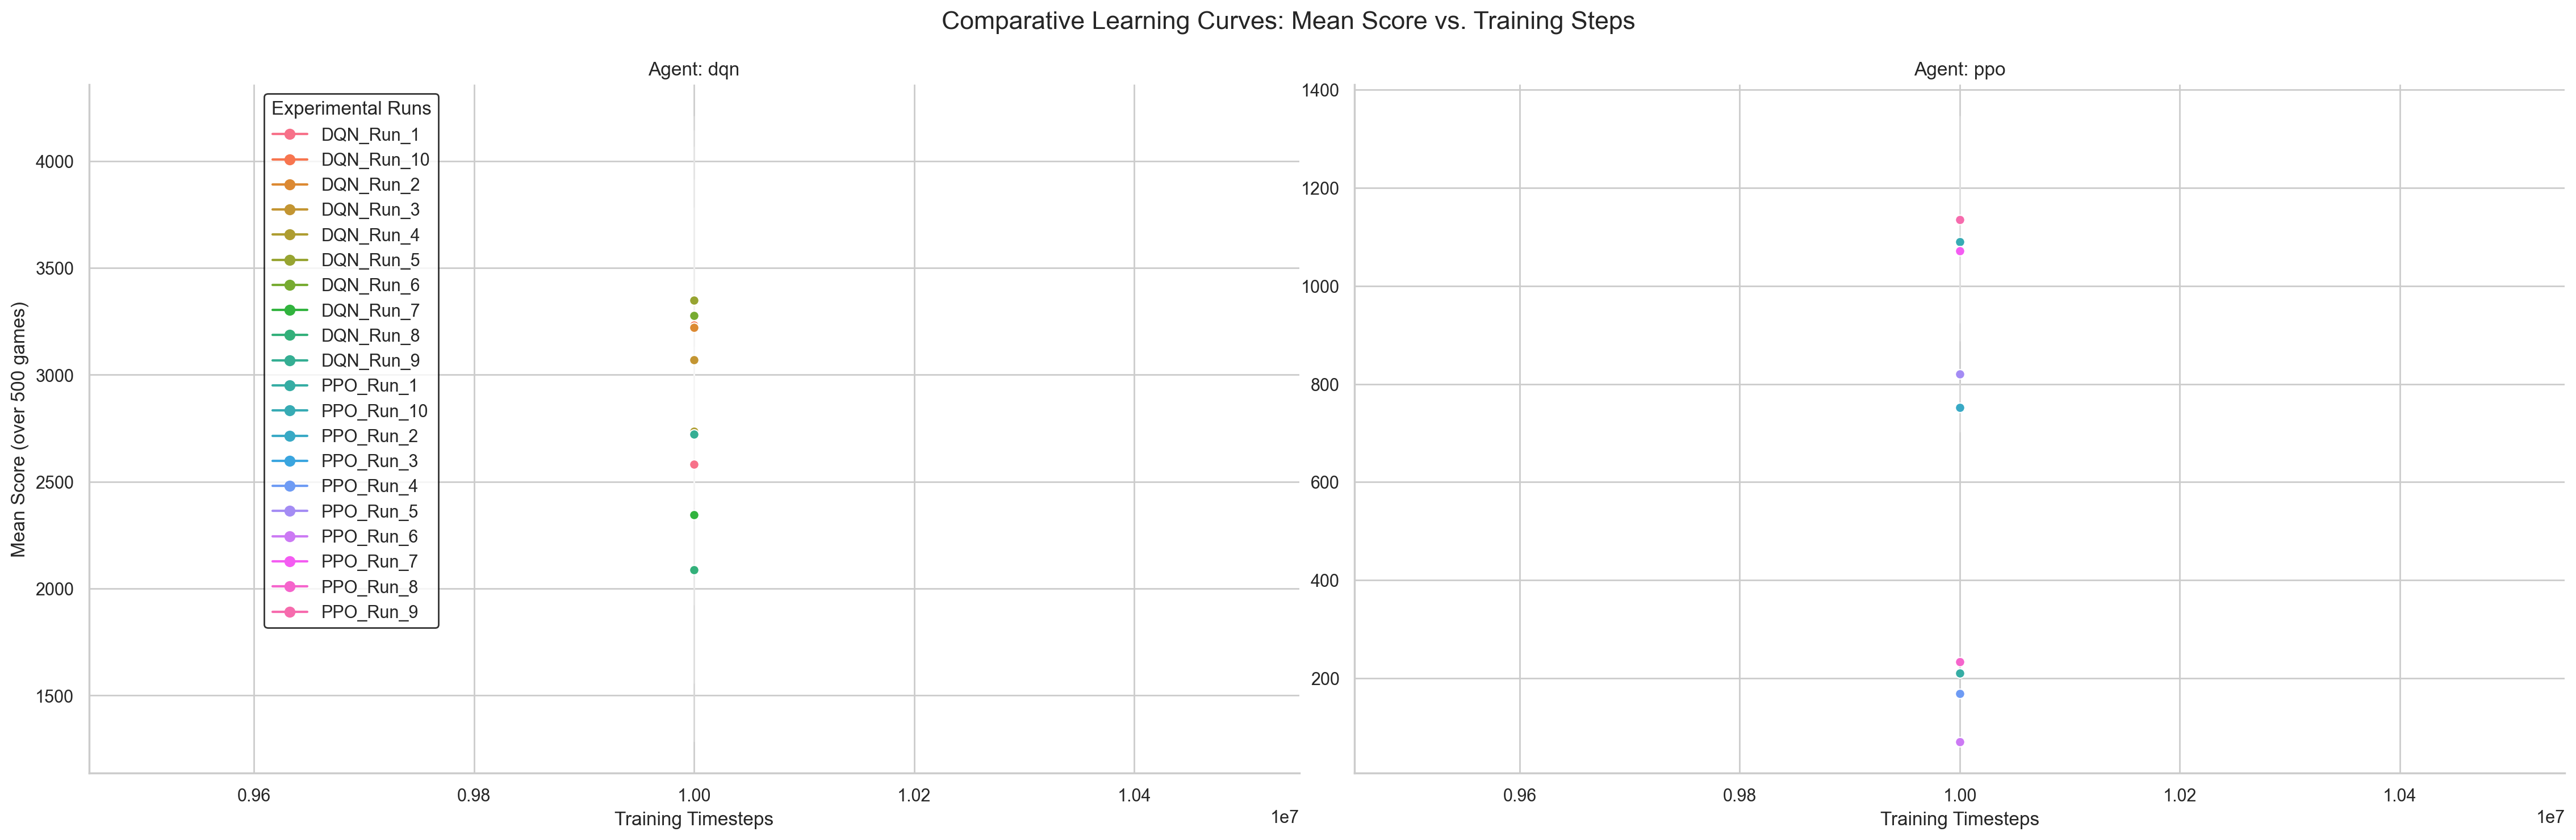


Generating final box-and-whisker plots...


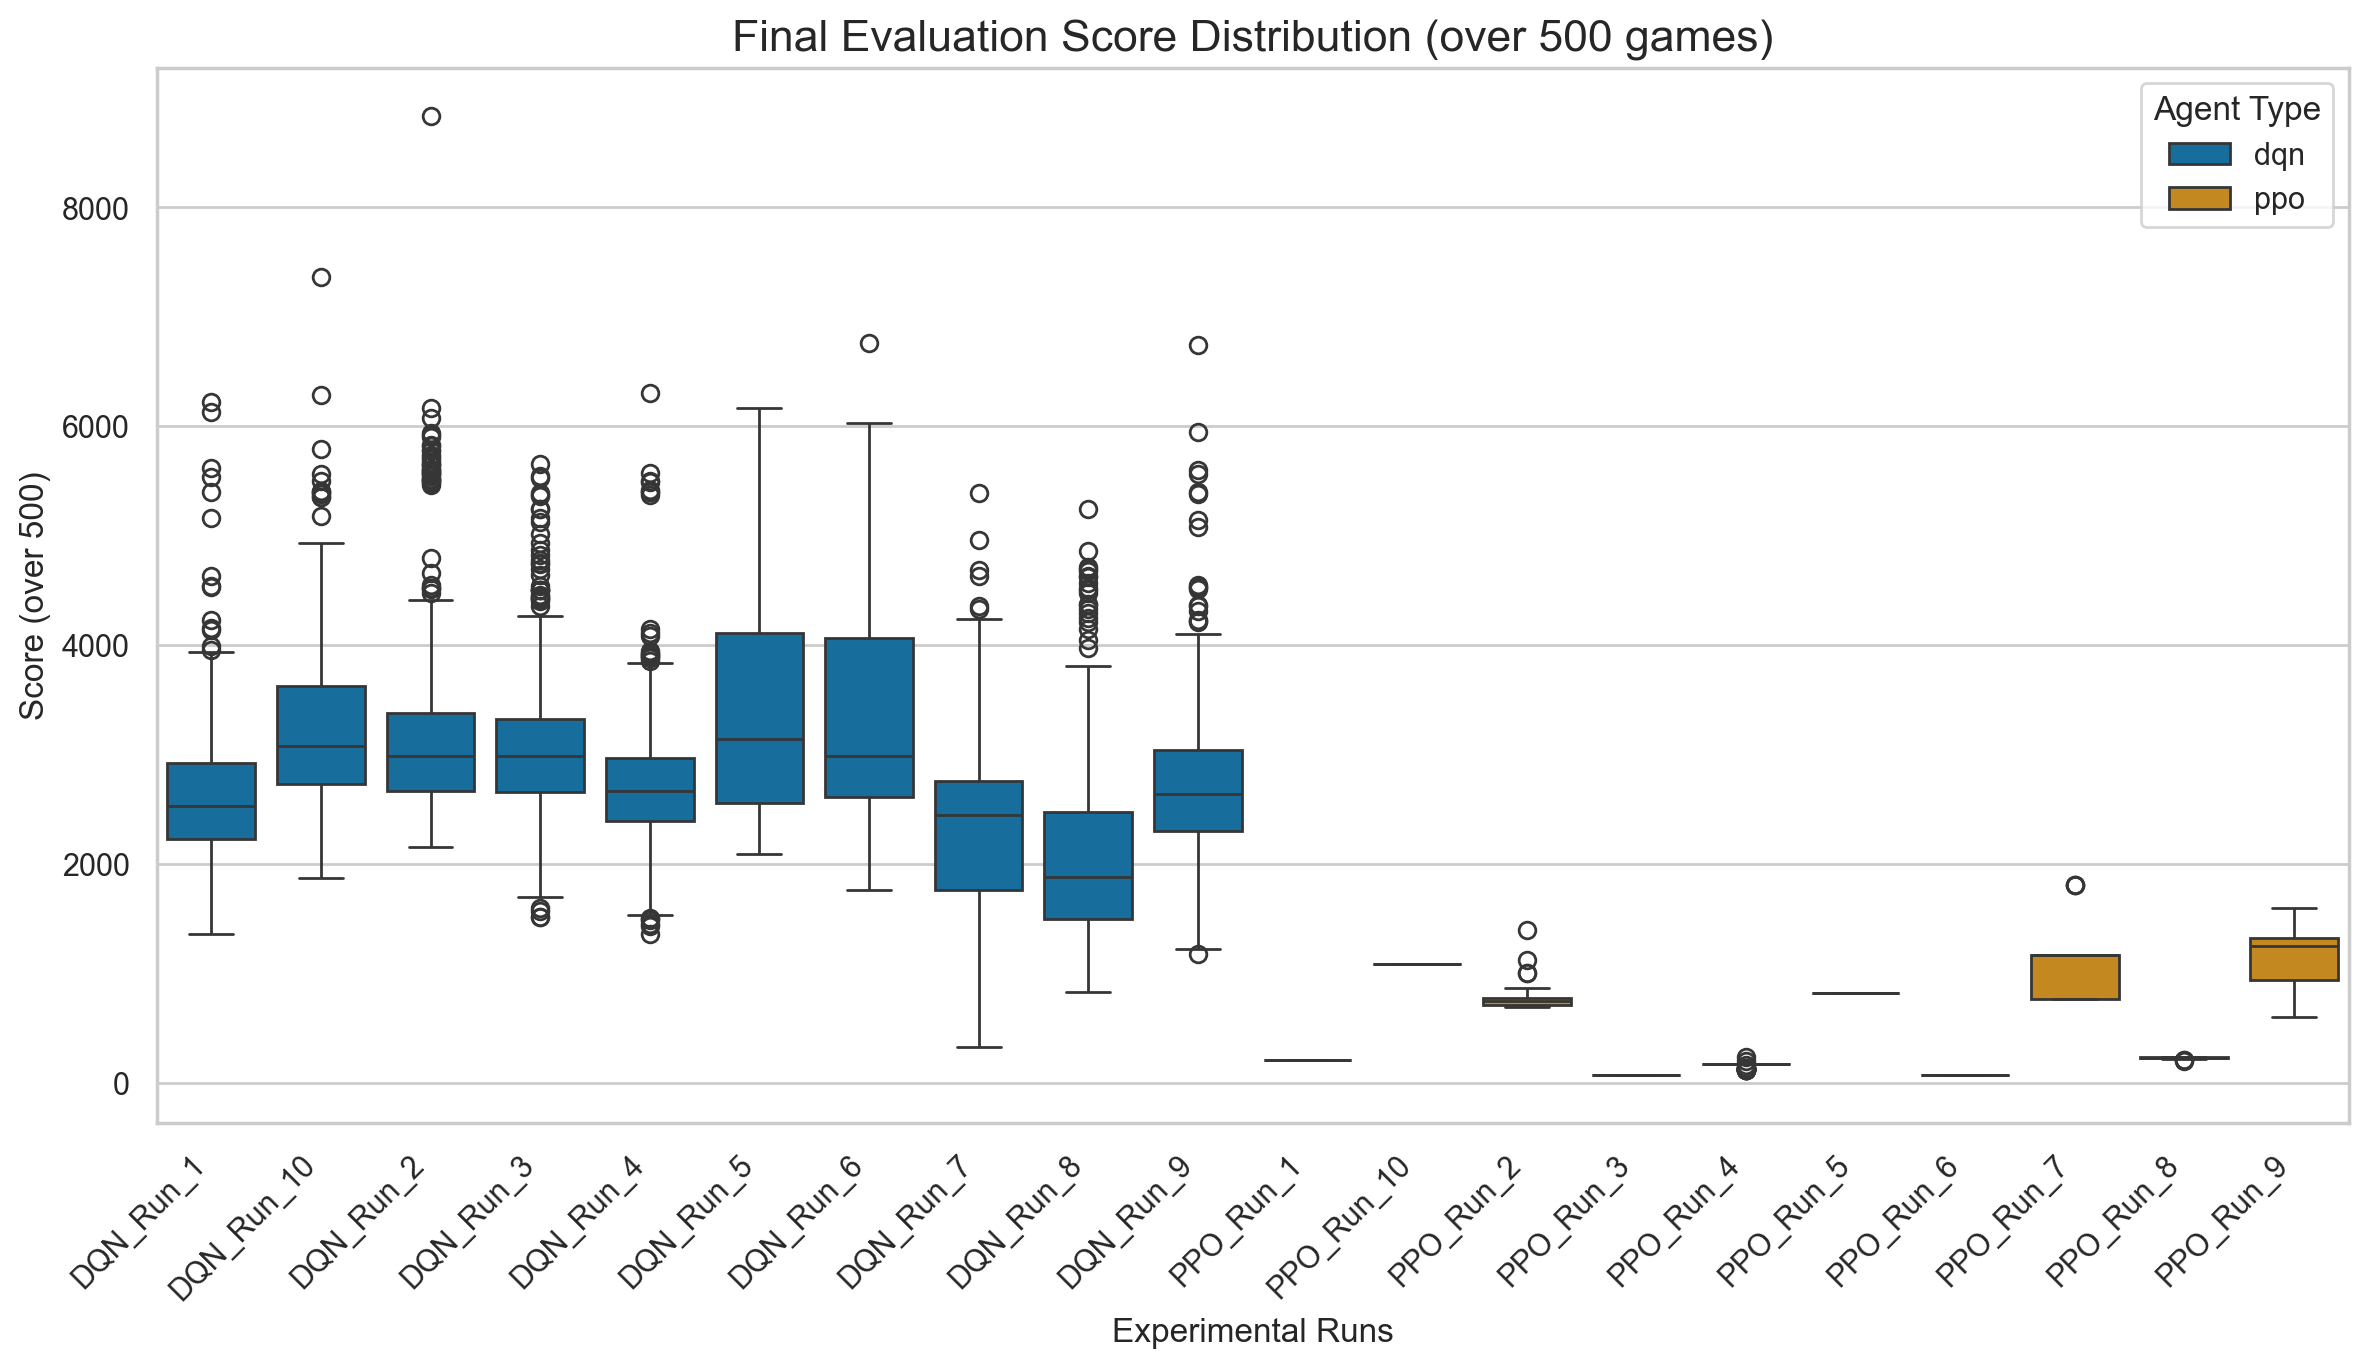

In [30]:
plot_comparative_learning_curves(master_summary_df=master_summary_df, num_eval_games=NUM_EVAL_GAMES)
plot_final_box_whisker(master_raw_df=master_raw_df, master_summary_df=master_summary_df, num_eval_games=NUM_EVAL_GAMES)


Generating comparative learning curves...


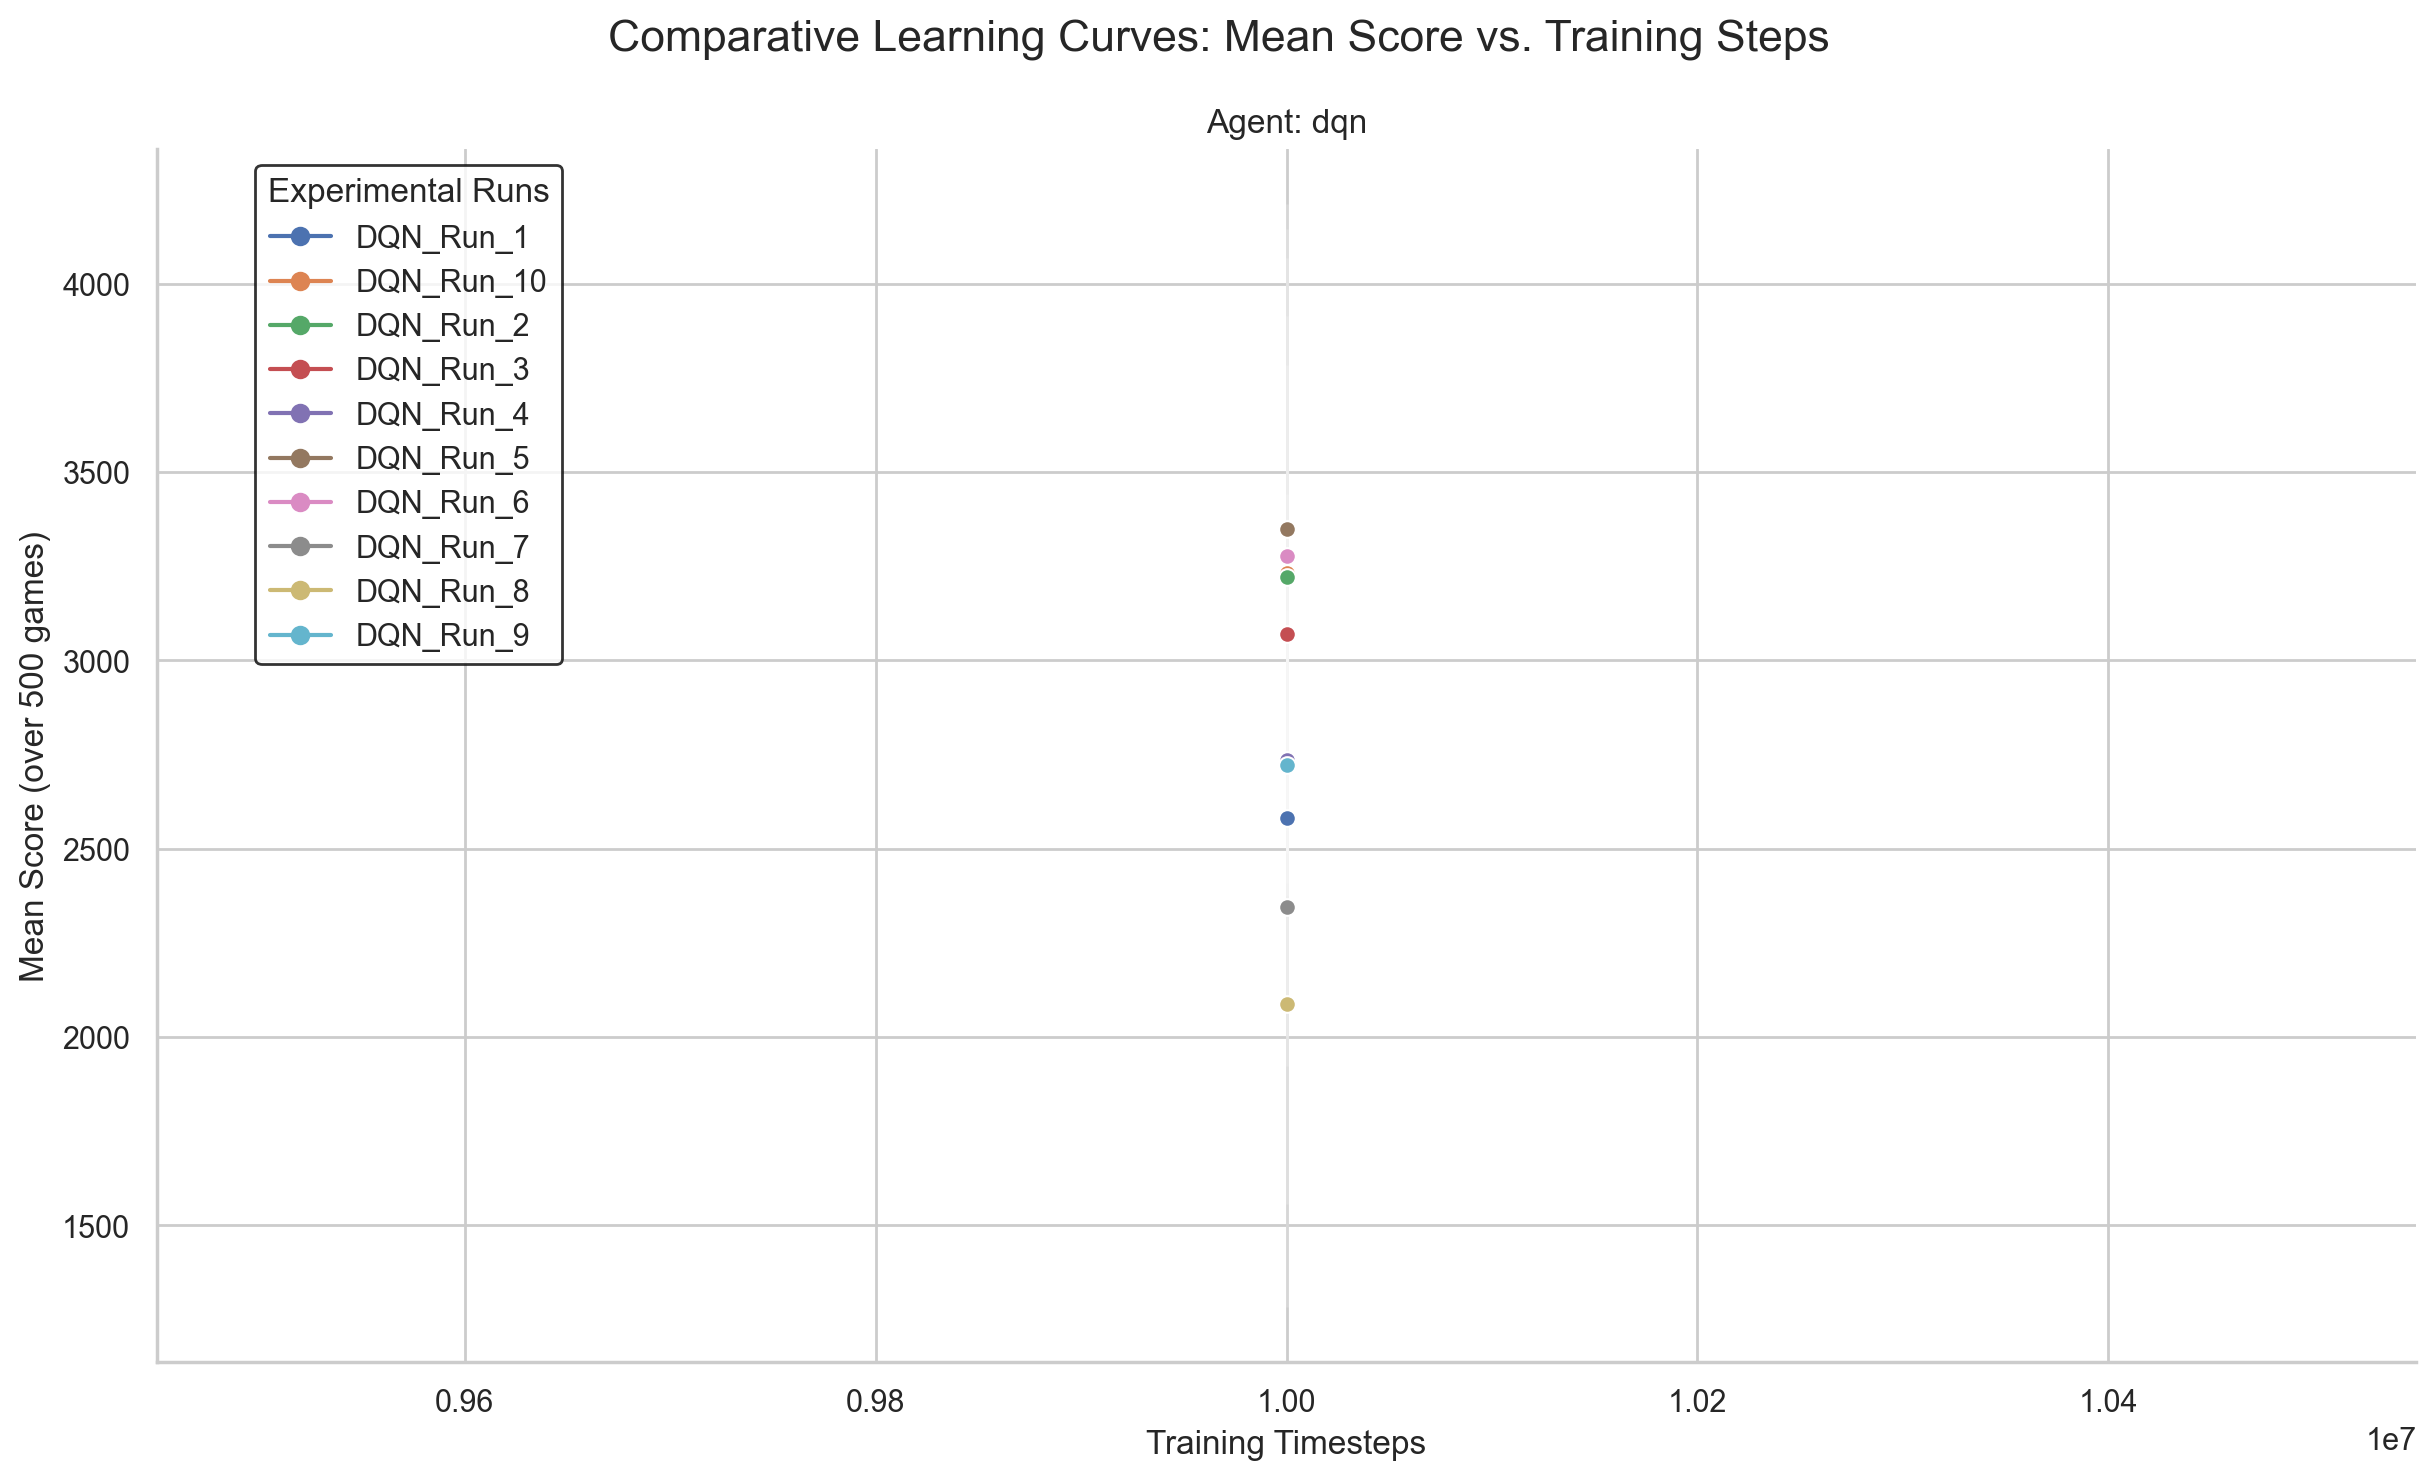


Generating comparative learning curves...


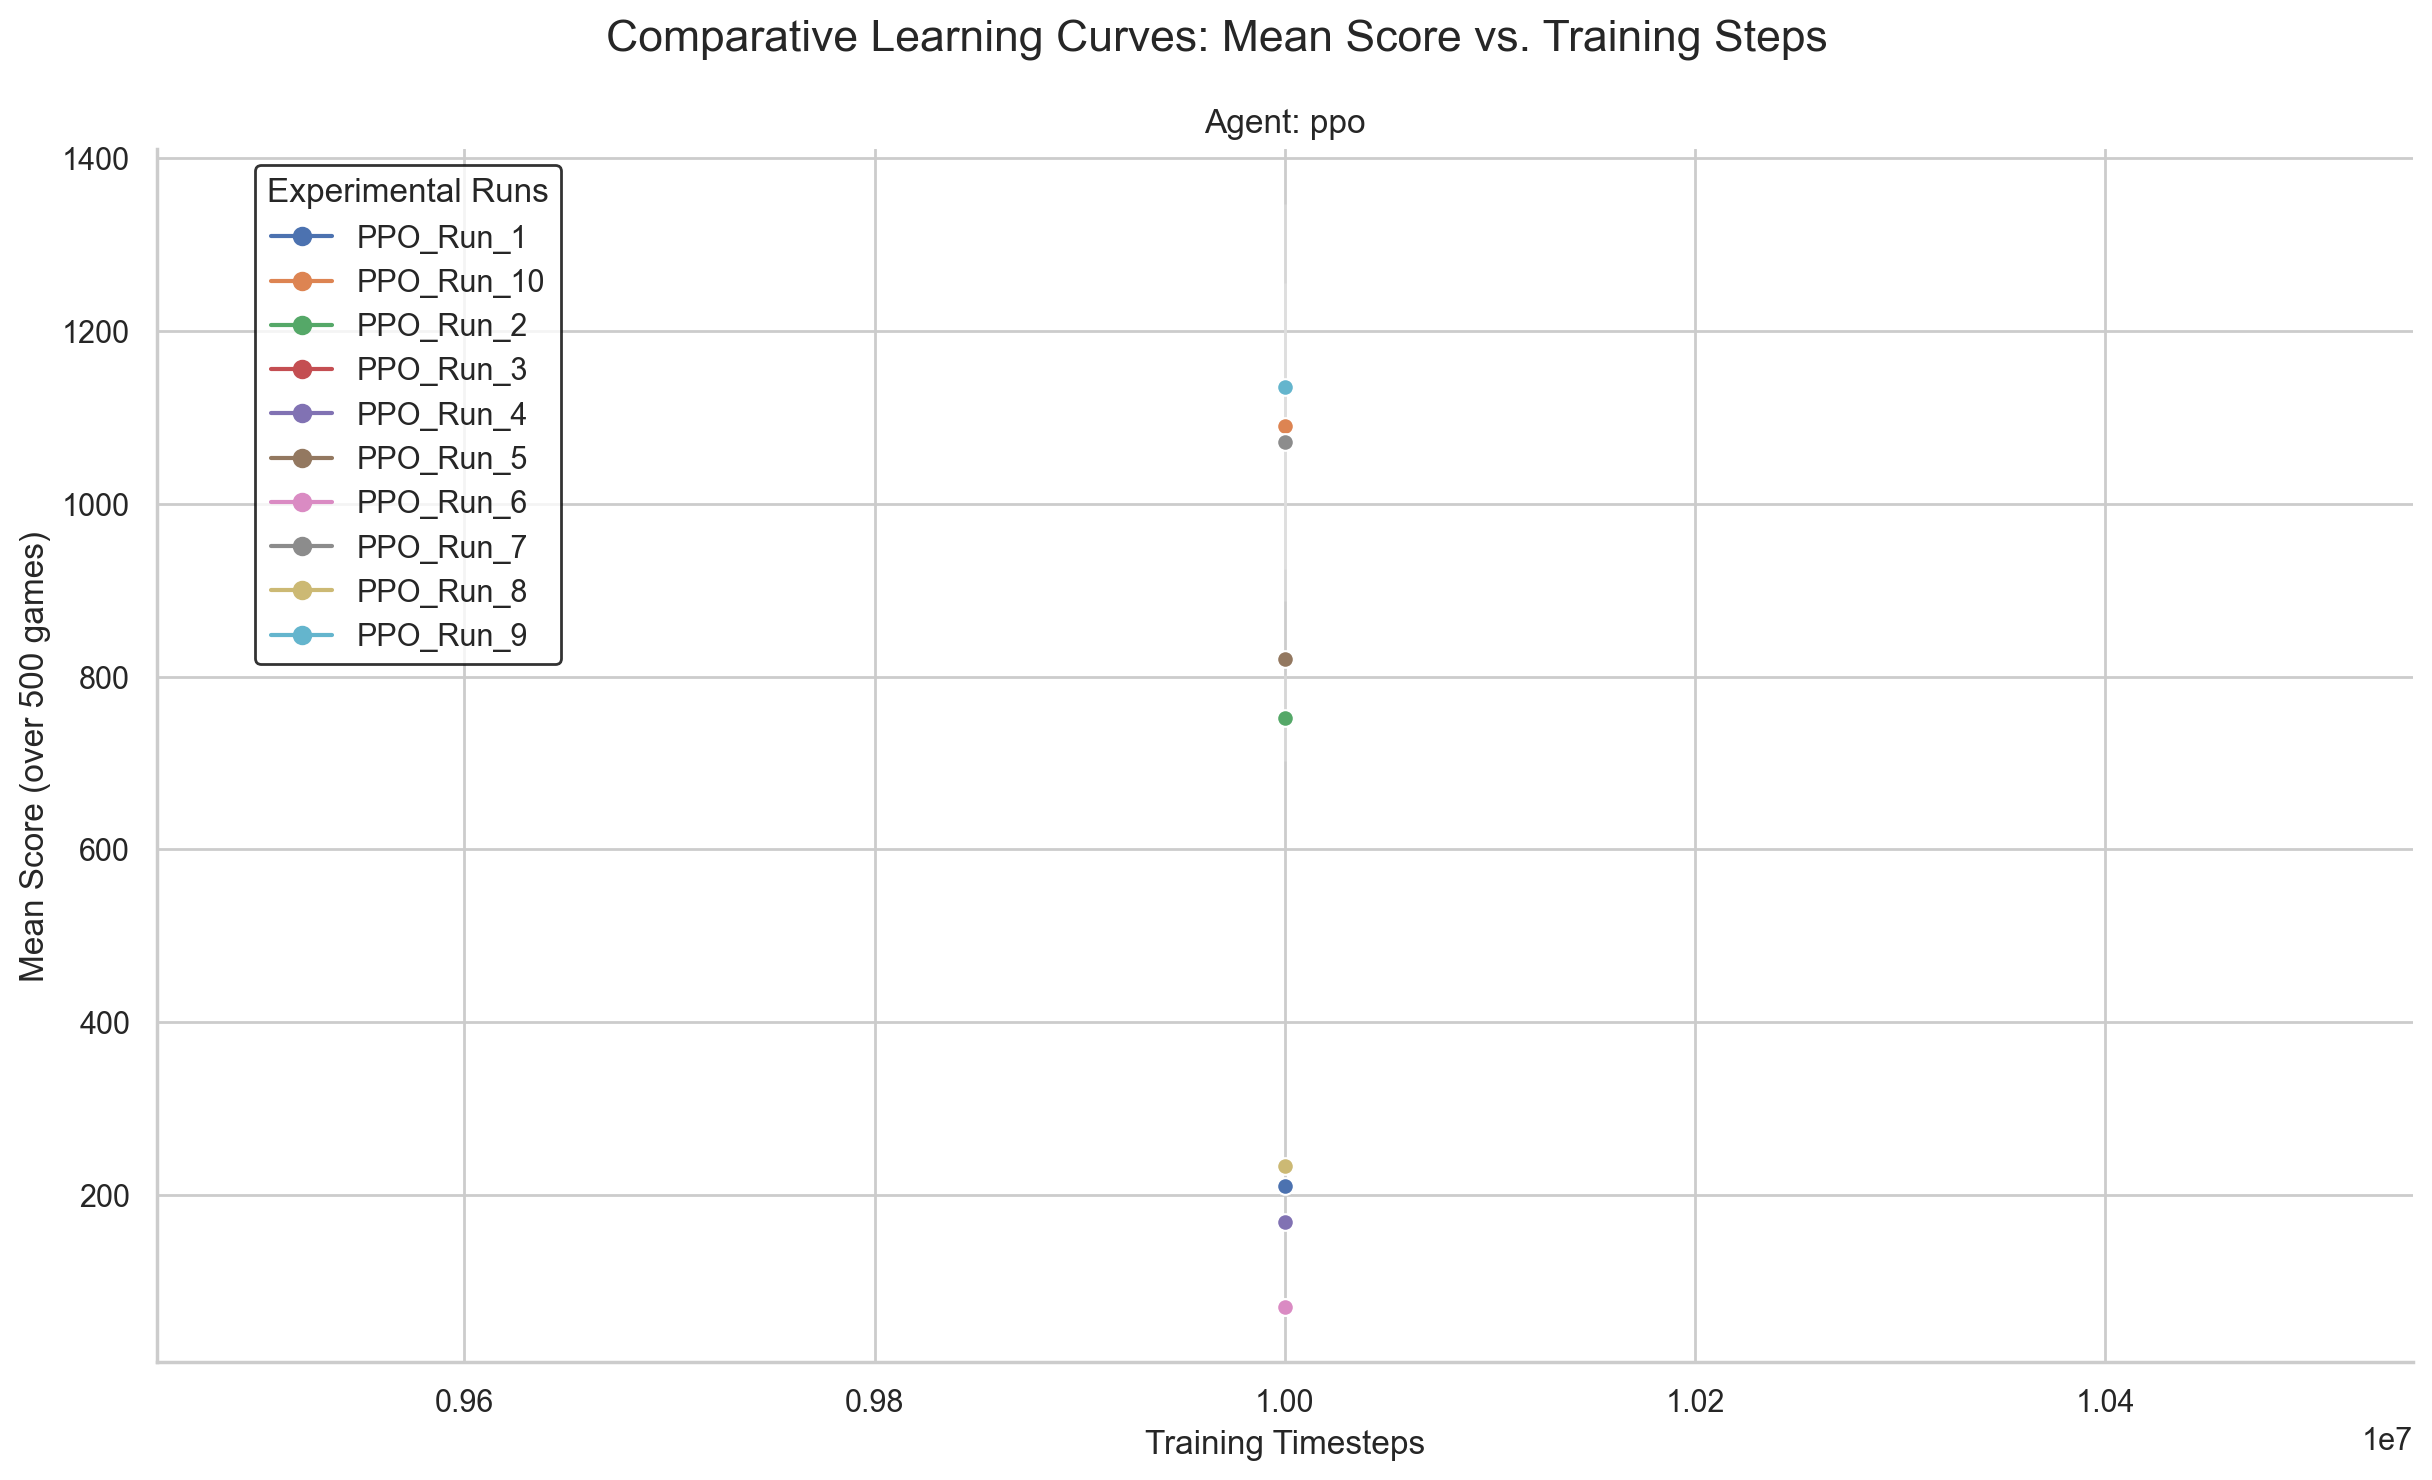

In [31]:
dqn_master_summary_df = master_summary_df[master_summary_df['agent_type'] == 'dqn']
ppo_master_summary_df = master_summary_df[master_summary_df['agent_type'] == 'ppo']
plot_comparative_learning_curves(master_summary_df=dqn_master_summary_df, num_eval_games=NUM_EVAL_GAMES)
plot_comparative_learning_curves(master_summary_df=ppo_master_summary_df, num_eval_games=NUM_EVAL_GAMES)

# Output dataset to CSV

In [32]:
# Output dataset to CSV
csv_filename = project_root / "evaluation_results.csv"
master_summary_df.to_csv(csv_filename, index=False)
print(f"\nMaster summary DataFrame saved to {csv_filename}")


Master summary DataFrame saved to g:\Github\DeepRL-MsPacman\evaluation_results.csv


# Create play video

In [33]:
print("--- Running Video Generation Test ---")

# --- ⚠️ USER CONFIGURATION ---
# Specify the run and checkpoint you want to create a video for.
# Make sure this run name and timestep correspond to an actual checkpoint file.
AGENT_TYPE_TO_TEST = 'dqn'
RUN_NAME_TO_TEST = 'DQN_Run_1'
TIMESTEP_TO_TEST = 10000000 # e.g., for '..._step_10000000.pth'

# Specify a custom, clean name for the output video file.
VIDEO_FILENAME = f"{RUN_NAME_TO_TEST}_step_{TIMESTEP_TO_TEST}_gameplay"
# --- End Configuration ---

try:
    generate_video(
        agent_type=AGENT_TYPE_TO_TEST,
        run_name=RUN_NAME_TO_TEST,
        checkpoint_timestep=TIMESTEP_TO_TEST,
        video_filename=VIDEO_FILENAME
    )
    print("\n✅ Test completed successfully.")
except FileNotFoundError as e:
    print(f"\n❌ Test failed: {e}")
    print("Please ensure the AGENT_TYPE, RUN_NAME, and TIMESTEP variables match your saved files.")
except Exception as e:
    print(f"\n❌ An unexpected error occurred during the test: {e}")



--- Running Video Generation Test ---
--- Generating video for DQN_Run_1 at timestep 10000000 ---
Using device: cuda
Environment created and wrapped with unified AtariWrapper.
DQN Agent instantiated.
Successfully loaded checkpoint: dqn_1_model_step_10000000.pth
Playing episode...


c:\Users\Alex\anaconda3\envs\mspacman_rl\Lib\site-packages\gymnasium\wrappers\record_video.py:94: UserWarning: WARN: Overwriting existing videos at g:\Github\DeepRL-MsPacman\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
c:\Users\Alex\anaconda3\envs\mspacman_rl\Lib\site-packages\gymnasium\utils\passive_env_checker.py:335: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(


MoviePy - Building video g:\Github\DeepRL-MsPacman\videos\DQN_Run_1_step_10000000_gameplay-episode-0.mp4.
MoviePy - Writing video g:\Github\DeepRL-MsPacman\videos\DQN_Run_1_step_10000000_gameplay-episode-0.mp4



MoviePy - Done !
MoviePy - video ready g:\Github\DeepRL-MsPacman\videos\DQN_Run_1_step_10000000_gameplay-episode-0.mp4
--- Video saved successfully to: g:\Github\DeepRL-MsPacman\videos\DQN_Run_1_step_10000000_gameplay.mp4 ---

✅ Test completed successfully.
